In [1]:
# GLOBAL CONFIGURATION ENGINE
# Change these inputs to run the analyzer on any publicly traded company.
# 1. Target Asset
TICKER_SYMBOL = "ADANIENT.NS"
TIME_PERIOD = "5y" #fixed

# 2. Macroeconomic Assumptions (India)
RISK_FREE_RATE = 0.07  # 7% 10-Year Govt Bond Yield
MARKET_RETURN = 0.12   # 12% Nifty 50 Expected Return
TAX_RATE = 0.30        # Standard Corporate Tax Rate

# library Requirements:  pip install yfinance pandas numpy matplotlib


  SUMMARY  —  ADANIENT.NS
  EBIT (latest FY) ............ 199175700000
  Interest Expense ............63929100000
  Interest Coverage Ratios .....
2026-03-31    3.115572
2025-03-31    3.143944
2024-03-31    2.324093
2023-03-31    2.078096
dtype: float64
----------------------------------------------------------
  Total Debt .................. 1066217900000
  Shareholder Equity .......... 809259500000
  Debt-to-Equity Ratios .............. 
2026-03-31    1.317523
2025-03-31    1.818036
2024-03-31    1.671358
2023-03-31    1.603963
2022-03-31         NaN
dtype: float64
----------------------------------------------------------
  Risk-free rate (input) ...... 7.00%
  Market return  (input) ...... 12.00%
  Beta ........................ 0.824
  Market Cap (Equity, E) ...... 4182092546048
  Tax Rate (effective) ........ 30.00%
  Cost of Equity (CAPM) ....... 11.12%
  Cost of Debt ................ 6.00%
  WACC ........................ 9.71%



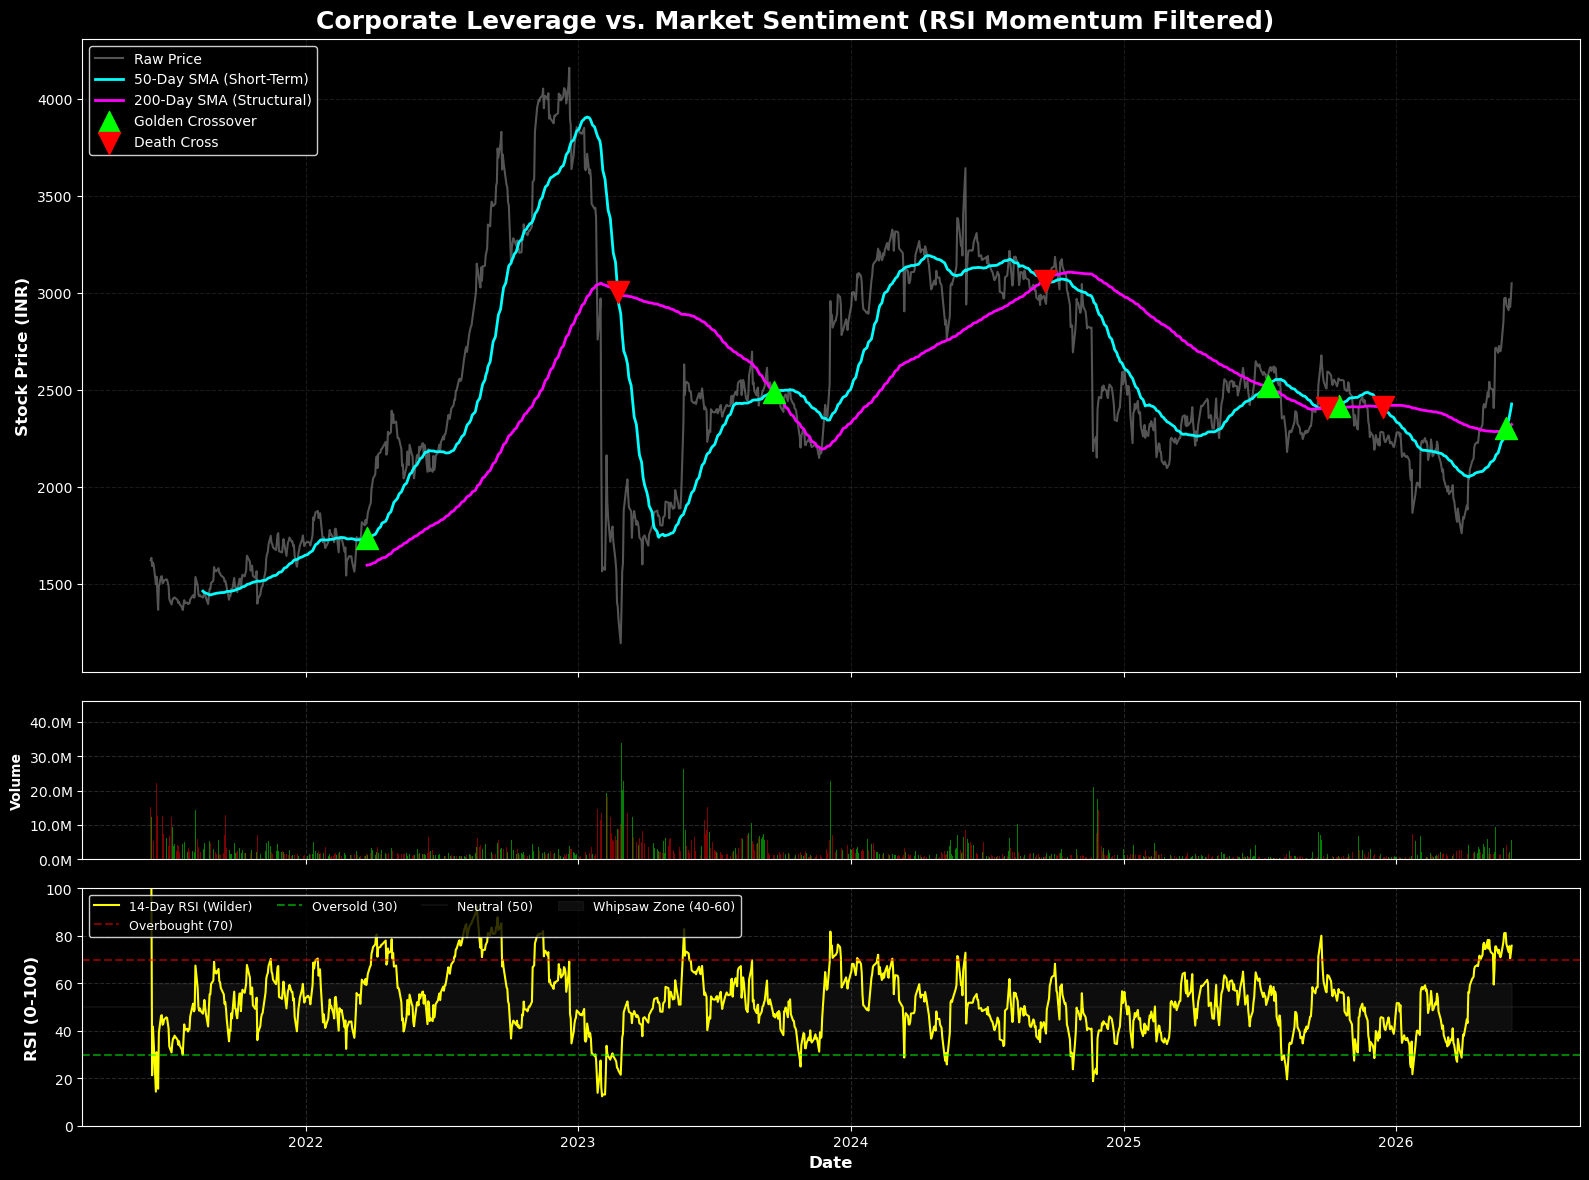




 RECENT CROSSOVERS ANALYSIS

Date: 2022-03-24
Signal Triggered: Golden Crossover (BULLISH) at ₹1829.54
RSI Reading: 61.11 -> NEUTRAL: Indecision Zone / Whipsaw. Lacks true momentum validation.

Date: 2023-02-23
Signal Triggered: Death Cross (BEARISH) at ₹1380.76
RSI Reading: 24.15 -> WARNING: Oversold. Panic dumping. Potential bargain bounce.

Date: 2023-09-21
Signal Triggered: Golden Crossover (BULLISH) at ₹2477.05
RSI Reading: 47.08 -> NEUTRAL: Indecision Zone / Whipsaw. Lacks true momentum validation.

Date: 2024-09-17
Signal Triggered: Death Cross (BEARISH) at ₹2973.73
RSI Reading: 42.51 -> NEUTRAL: Indecision Zone / Whipsaw. Lacks true momentum validation.

Date: 2025-07-14
Signal Triggered: Golden Crossover (BULLISH) at ₹2581.30
RSI Reading: 54.14 -> NEUTRAL: Indecision Zone / Whipsaw. Lacks true momentum validation.

Date: 2025-09-30
Signal Triggered: Death Cross (BEARISH) at ₹2505.90
RSI Reading: 56.20 -> NEUTRAL: Indecision Zone / Whipsaw. Lacks true momentum validation.

D

In [3]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

target = yf.Ticker(TICKER_SYMBOL)
hist_data = target.history(period=TIME_PERIOD)
income_stmt = target.financials
balance_sheet = target.balance_sheet
bs_t=balance_sheet.T
inc_t=income_stmt.T 

#interest coverage ratio
ebit = inc_t['EBIT']
interest_expense = inc_t['Interest Expense']
interest_coverage_ratio = abs(ebit / interest_expense)
clean_icr=interest_coverage_ratio.iloc[:5]

#Debt to Equity Ratio
total_debt = bs_t['Total Debt']
total_equity = bs_t['Stockholders Equity']
de = total_debt / total_equity
clean_de = de.iloc[:5]

#cost of Equity(Ke)
Rf=RISK_FREE_RATE
Rm=MARKET_RETURN
live_beta=target.info.get("beta")
if live_beta != 'Data missing':
    Ke= Rf+live_beta*(Rm-Rf)
else:
    print("beta missing")

#tax rate
tax_rate = TAX_RATE

#cost of Debt(Kd)
market_cap= target.info.get('marketCap')
recent_debt= bs_t['Total Debt'].iloc[0]
recent_interest=inc_t['Interest Expense'].iloc[0]
Kd= abs(recent_interest / recent_debt)

#weights
total_cap= market_cap+recent_debt
weight_equity=market_cap/total_cap
weight_debt=recent_debt/total_cap

#WACC
WACC=(weight_equity*Ke)+(weight_debt*Kd*(1-tax_rate))

#Deploying J. Welles Wilder’s EWMA smoothing
hist_data['50_SMA'] = hist_data['Close'].rolling(window=50).mean()
hist_data['200_SMA'] = hist_data['Close'].rolling(window=200).mean()
hist_data['Sentiment_Signal'] = np.where(hist_data['50_SMA'] > hist_data['200_SMA'], 1, 0)

hist_data['Position_Change'] = hist_data['Sentiment_Signal'].diff()
crossovers = hist_data[(hist_data['Position_Change'] == 1)
| (hist_data['Position_Change'] == -1)].copy()
crossovers['Signal_Type'] = crossovers['Position_Change'].map({1.0: 'Golden Crossover', -1.0: 'Death Cross'})

delta = hist_data['Close'].diff()
gain = delta.where(delta > 0, 0.0)
loss = -delta.where(delta < 0, 0.0)
avg_gain = gain.ewm(alpha=1/14, adjust=False).mean()
avg_loss = loss.ewm(alpha=1/14, adjust=False).mean()
rs = avg_gain / avg_loss
hist_data['RSI_14'] = 100 - (100 / (1 + rs))
crossovers = hist_data[(hist_data['Position_Change'] == 1) | (hist_data['Position_Change'] == -1)].dropna()

#displaying information
#print_fundamentals(ticker, f, rf, rm):
print("\n" + "=" * 58)
print(f"  SUMMARY  —  {TICKER_SYMBOL}")
print("=" * 58)
print(f"  EBIT (latest FY) ............ {ebit.iloc[0]:.0f}")
print(f"  Interest Expense ............{interest_expense.iloc[0]:.0f}")
print(f"  Interest Coverage Ratios .....")
print(f"{clean_icr}")
print("-" * 58)
print(f"  Total Debt .................. {total_debt.iloc[0]:.0f}")
print(f"  Shareholder Equity .......... {total_equity.iloc[0]:.0f}")
print(f"  Debt-to-Equity Ratios .............. " )
print(f"{clean_de}")
print("-" * 58)
print(f"  Risk-free rate (input) ...... {100*RISK_FREE_RATE:.2f}%")
print(f"  Market return  (input) ...... {100*MARKET_RETURN:.2f}%")
print(f"  Beta ........................ {live_beta}")
print(f"  Market Cap (Equity, E) ...... {market_cap}")
print(f"  Tax Rate (effective) ........ { 100*tax_rate:.2f}%")
print(f"  Cost of Equity (CAPM) ....... {f'{Ke * 100:.2f}%' if Ke is not None else 'None'}")
print(f"  Cost of Debt ................ { f'{Kd * 100:.2f}%' if Kd is not None else 'None'}")
print(f"  WACC ........................ {f'{WACC * 100:.2f}%' if WACC is not None else 'None'}")
print("=" * 58 + "\n")


#plotting
plt.style.use('dark_background')
fig, (ax1, ax2,ax3) = plt.subplots(3, 1, gridspec_kw={'height_ratios': [4, 1,1.5]}, figsize=(16, 12), sharex=True)
fig.suptitle('Corporate Leverage vs. Market Sentiment (RSI Momentum Filtered)', fontsize=18, fontweight='bold', color='white')

ax1.plot(hist_data.index, hist_data['Close'], label='Raw Price', color='lightgray', alpha=0.4, linewidth=1.5)
ax1.plot(hist_data.index, hist_data['50_SMA'], label='50-Day SMA (Short-Term)', color='cyan', linewidth=2)
ax1.plot(hist_data.index, hist_data['200_SMA'], label='200-Day SMA (Structural)', color='magenta', linewidth=2)

golden = crossovers[crossovers['Position_Change'] == 1]
death = crossovers[crossovers['Position_Change'] == -1]

ax1.scatter(golden.index, golden['50_SMA'], color='lime', marker='^', s=250, label='Golden Crossover', zorder=5)
ax1.scatter(death.index, death['50_SMA'], color='red', marker='v', s=250, label='Death Cross', zorder=5)

ax1.set_ylabel('Stock Price (INR)', fontsize=12, fontweight='bold')
ax1.legend(loc='upper left', facecolor='black', edgecolor='white')
ax1.grid(color='gray', linestyle='--', alpha=0.2)

colors = np.where(hist_data['Close'] >= hist_data['Open'], 'lime', 'red')
ax2.bar(hist_data.index, hist_data['Volume'], color=colors, alpha=0.5)
formatter = mticker.FuncFormatter(lambda x, pos: f'{x * 1e-6:.1f}M')
ax2.yaxis.set_major_formatter(formatter)

ax2.set_ylabel('Volume', fontsize=10, fontweight='bold')
ax2.grid(color='gray', linestyle='--', alpha=0.3)

#RSI oscillator
ax3.plot(hist_data.index, hist_data['RSI_14'], label='14-Day RSI (Wilder)', color='yellow', linewidth=1.5)

ax3.axhline(70, color='red', linestyle='--', alpha=0.5, label='Overbought (70)')
ax3.axhline(30, color='lime', linestyle='--', alpha=0.5, label='Oversold (30)')
ax3.axhline(50, color='gray', linestyle='-', alpha=0.1, label='Neutral (50)')

ax3.fill_between(hist_data.index, 40, 60, color='gray', alpha=0.1, label='Whipsaw Zone (40-60)')

ax3.set_ylabel('RSI (0-100)', fontsize=12, fontweight='bold')
ax3.set_xlabel('Date', fontsize=12, fontweight='bold')
ax3.set_ylim(0, 100)
ax3.legend(loc='upper left', fontsize=9, facecolor='black', edgecolor='white', ncol=4)
ax3.grid(color='gray', linestyle='--', alpha=0.3)


plt.tight_layout()
plt.show()
live_wacc = f"{WACC:.2%}"
live_icr = round(clean_icr, 2)
live_de = round(clean_de, 2)
hud_text = (
    f"--- FUNDAMENTAL SCORECARD ---\n"
    f"Target Asset: {TICKER_SYMBOL} Time Period:{TIME_PERIOD}\n"
    f"WACC: {live_wacc}\n"
    f"Latest ICR:{live_icr}x\n"
    f"Latest DE:{live_de}x"
)
props = dict(boxstyle='round', facecolor='black', alpha=0.8, edgecolor='gray')
ax1.text(0.02, 0.05, hud_text, transform=ax1.transAxes, fontsize=10, 
         verticalalignment='bottom', bbox=props, color='white', family='monospace')
plt.show()




print("\n")
print("\n"+ "=" * 58)
print(f" RECENT CROSSOVERS ANALYSIS")
print("=" * 58)
for date, row in crossovers.iterrows():
    signal_type = "Golden Crossover (BULLISH)" if row['Position_Change'] == 1 else "Death Cross (BEARISH)"
    rsi_val = row['RSI_14']
    close_price = row['Close']
    if rsi_val > 70:
        verdict = "WARNING: Overbought. Mania driving price. High risk of reversal."
    elif rsi_val < 30:
        verdict = "WARNING: Oversold. Panic dumping. Potential bargain bounce."
    else:
        verdict = "NEUTRAL: Indecision Zone / Whipsaw. Lacks true momentum validation."
        
    print(f"\nDate: {date.strftime('%Y-%m-%d')}")
    print(f"Signal Triggered: {signal_type} at ₹{close_price:.2f}")
    print(f"RSI Reading: {rsi_val:.2f} -> {verdict}")


